In [4]:
import scipy
import functools
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import importlib
from scipy import stats
from datasets import Dataset, Audio, Features, Value, Sequence, load_from_disk, concatenate_datasets
from sklearn.metrics import f1_score
from scipy.stats import ttest_rel
from scipy.stats import ttest_ind
from scipy.stats import pearsonr
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, r2_score
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
import matplotlib.cm as cm

In [2]:
mpl.rcParams.update({
    'font.family'         : 'serif',       # Computer Modern — the default LaTeX font
    'font.size'           : 10,            # body text size (most journals use 10 pt)
    'axes.labelsize'      : 10,            # axis-label size matches body text
    'xtick.labelsize'     : 9,             # tick labels one point smaller
    'ytick.labelsize'     : 9,
    'legend.fontsize'     : 9,             # legend text one point smaller
    'axes.prop_cycle'     : mpl.cycler('color', [   # Okabe–Ito colorblind-safe palette
        '#0072B2', '#D55E00', '#009E73',
        '#E69F00', '#CC79A7', '#56B4E9',
    ]),
    'lines.linewidth'     : 1.5,           # slightly thicker for print clarity
    'axes.linewidth'      : 0.8,           # thinner axis frame
    'xtick.direction'     : 'in',          # inward ticks — journal standard
    'ytick.direction'     : 'in',
    'xtick.minor.visible' : True,          # show minor ticks
    'ytick.minor.visible' : True,
    'xtick.major.size'    : 4,             # longer than the 3.5 default
    'ytick.major.size'    : 4,
    'xtick.minor.size'    : 2,             # half of major — proportional
    'ytick.minor.size'    : 2,
    'xtick.major.width'   : 0.8,           # match axes.linewidth
    'ytick.major.width'   : 0.8,
    'xtick.minor.width'   : 0.6,           # thinner for visual hierarchy
    'ytick.minor.width'   : 0.6,
    'lines.markersize'    : 4,             # smaller markers for print scale
    'errorbar.capsize'    : 3,             # visible end-caps (default is 0)
    'axes.xmargin'        : 0.02,          # hug the data (default is 0.05)
    'axes.ymargin'        : 0.02,
    'legend.frameon'      : False,         # no legend box
    'savefig.bbox'        : 'tight',       # tight bounding box by default
    'savefig.dpi'         : 300,           # publication-quality resolution
    **(                                    # LaTeX if installed, else fallback
        {'text.usetex'        : True,              # real LaTeX for all text
         'text.latex.preamble': r'\usepackage{amsmath} \usepackage{amssymb}',
         'pgf.texsystem'     : 'pdflatex',         # consistent PGF export
         'pgf.rcfonts'       : False}               # let LaTeX control fonts
        if __import__('shutil').which('latex') else
        {'text.usetex'        : False,             # no TeX install found
         'mathtext.fontset'  : 'cm'}               # Computer Modern via mathtext
    ),
})

In [3]:
def pearson_with_ci(x, y, alpha=0.05):
    r, p = pearsonr(x, y)
    n = len(x)
    # fisher z transformation for CI
    z = np.arctanh(r)
    se = 1 / np.sqrt(n - 3)
    z_crit = stats.norm.ppf(1 - alpha/2)
    ci_low = np.tanh(z - z_crit * se)
    ci_high = np.tanh(z + z_crit * se)
    return r, p, ci_low, ci_high

In [14]:
def analyze_embeddings(epoch):
    
    embedding_cols = [str(i) for i in range(768)]
    epe_epoch = epe[epe['epoch'] == epoch].reset_index(drop=True)
    X_emb = epe_epoch[embedding_cols].values
    y_emb = epe_epoch['labels'].values
    alphas = [1.0, 10.0, 100.0]

    # ── LEAVE-ONE-SEGMENT-OUT ─────────────────────────────────────────
    # select alpha via inner LOSO on training folds
    best_alpha_loso = None
    best_r_loso_inner = -np.inf

    for alpha in alphas:
        X_tr_inner, X_val_inner, y_tr_inner, y_val_inner = train_test_split(
            X_emb, y_emb, test_size=0.2, random_state=42
        )
        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr_inner)
        X_val_s = scaler.transform(X_val_inner)
        ridge = Ridge(alpha=alpha)
        ridge.fit(X_tr_s, y_tr_inner)
        r_inner, _, _, _ = pearson_with_ci(ridge.predict(X_val_s), y_val_inner)
        if r_inner > best_r_loso_inner:
            best_r_loso_inner = r_inner
            best_alpha_loso = alpha

    # now evaluate with best alpha
    loso_preds, loso_actuals = [], []
    for i in range(len(X_emb)):
        mask = np.ones(len(X_emb), dtype=bool)
        mask[i] = False
        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_emb[mask])
        X_te_s = scaler.transform(X_emb[i:i+1])
        ridge = Ridge(alpha=best_alpha_loso)
        ridge.fit(X_tr_s, y_emb[mask])
        loso_preds.append(ridge.predict(X_te_s)[0])
        loso_actuals.append(y_emb[i])

    R2_loso = r2_score(loso_actuals, loso_preds)
    r_loso, p_loso, lo_loso, hi_loso = pearson_with_ci(np.array(loso_preds), np.array(loso_actuals))
    print(f"Epoch {epoch} | LOSO (segment-level, alpha={best_alpha_loso}): R²={R2_loso:.3f}, r={r_loso:.3f}, 95% CI [{lo_loso:.3f}, {hi_loso:.3f}], p={p_loso:.3f}")

    # ── LEAVE-ONE-PARTICIPANT-OUT ─────────────────────────────────────
    unique_participants = epe_epoch['participant'].unique()
    best_alpha_lopo = None
    best_r_lopo_inner = -np.inf

    for alpha in alphas:
        inner_preds, inner_actuals = [], []
        for p_out in unique_participants:
            train_mask = epe_epoch['participant'] != p_out
            X_tr = epe_epoch[train_mask][embedding_cols].values
            y_tr = epe_epoch[train_mask]['labels'].values

            # inner val: leave one more participant out from training data
            inner_participants = epe_epoch[train_mask]['participant'].unique()
            for p_inner in inner_participants:
                inner_train = epe_epoch[train_mask & (epe_epoch['participant'] != p_inner)]
                inner_val = epe_epoch[train_mask & (epe_epoch['participant'] == p_inner)]
                X_itr = inner_train[embedding_cols].values
                y_itr = inner_train['labels'].values
                X_ival = inner_val[embedding_cols].values
                y_ival = inner_val['labels'].values
                scaler = StandardScaler()
                X_itr_s = scaler.fit_transform(X_itr)
                X_ival_s = scaler.transform(X_ival)
                ridge = Ridge(alpha=alpha)
                ridge.fit(X_itr_s, y_itr)
                inner_preds.append(ridge.predict(X_ival_s).mean())
                inner_actuals.append(y_ival[0])

        r_inner, _, _, _ = pearson_with_ci(np.array(inner_preds), np.array(inner_actuals))
        if r_inner > best_r_lopo_inner:
            best_r_lopo_inner = r_inner
            best_alpha_lopo = alpha

    # now evaluate with best alpha
    loo_preds, loo_actuals = [], []
    for p_out in unique_participants:
        train_mask = epe_epoch['participant'] != p_out
        test_mask = epe_epoch['participant'] == p_out
        X_tr = epe_epoch[train_mask][embedding_cols].values
        y_tr = epe_epoch[train_mask]['labels'].values
        X_te = epe_epoch[test_mask][embedding_cols].values
        y_te = epe_epoch[test_mask]['labels'].values
        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_te_s = scaler.transform(X_te)
        ridge = Ridge(alpha=best_alpha_lopo)
        ridge.fit(X_tr_s, y_tr)
        loo_preds.append(ridge.predict(X_te_s).mean())
        loo_actuals.append(y_te[0])

    R2_lopo = r2_score(loo_actuals, loo_preds)
    r_loo, p_loo, lo_loo, hi_loo = pearson_with_ci(np.array(loo_preds), np.array(loo_actuals))
    print(f"Epoch {epoch} | LOPO (participant-level, alpha={best_alpha_lopo}): R²={R2_lopo:.3f}, r={r_loo:.3f}, 95% CI [{lo_loo:.3f}, {hi_loo:.3f}], p={p_loo:.3f}")

In [18]:
analyze_embeddings(0)

Epoch 0 | LOSO (segment-level, alpha=10.0): R²=0.755, r=0.870, 95% CI [0.858, 0.881], p=0.000
Epoch 0 | LOPO (participant-level, alpha=100.0): R²=-0.401, r=-0.184, 95% CI [-0.447, 0.109], p=0.216


In [15]:
analyze_embeddings(20)

Epoch 20 | LOSO (segment-level, alpha=10.0): R²=0.767, r=0.877, 95% CI [0.865, 0.887], p=0.000
Epoch 20 | LOPO (participant-level, alpha=100.0): R²=-0.407, r=-0.159, 95% CI [-0.427, 0.134], p=0.285


In [32]:
epe = pd.read_parquet(r"...\embeddings_per_epoch.parquet")

In [35]:
es = pd.read_parquet(r"...\epoch_stats.parquet")
epe = pd.read_parquet(r"...\embeddings_per_epoch_final_model.parquet")
sp = pd.read_parquet(r"...\scatter_participant.parquet")
ss = pd.read_parquet(r"...\scatter_segment.parquet")

In [64]:
threshold = 10.0 / 24.0

actual_binary = (sp['mean_actuals'] >= threshold).astype(int)
pred_binary = (sp['mean_preds'] >= threshold).astype(int)

print(classification_report(actual_binary, pred_binary, target_names=['non-depressed', 'depressed']))

               precision    recall  f1-score   support

non-depressed       0.77      0.94      0.85        35
    depressed       0.50      0.17      0.25        12

     accuracy                           0.74        47
    macro avg       0.63      0.55      0.55        47
 weighted avg       0.70      0.74      0.69        47



In [49]:
thresholds = np.arange(0, 1, 0.001)
f1_scores = [f1_score((sp['mean_actuals'] >= 10/24).astype(int),
                       (sp['mean_preds'] >= t).astype(int))
             for t in thresholds]

best_threshold = thresholds[np.argmax(f1_scores)]
print(f'Best threshold: {best_threshold:.5f} (= {best_threshold*24:.1f} PHQ), F1: {max(f1_scores):.3f}')

Best threshold: 0.32900 (= 7.9 PHQ), F1: 0.468


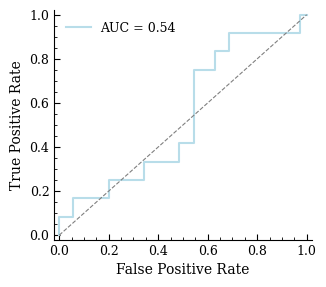

In [50]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve((sp['mean_actuals'] >= 10/24).astype(int), sp['mean_preds'])
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(80/25.4, 70/25.4), layout='constrained')
ax.plot(fpr, tpr, color='#B8DDE9', linewidth=1.5, label=f'AUC = {roc_auc:.2f}')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
fig.savefig('final_roc_curve.pdf')

In [19]:
woz_features = pd.read_pickle("woz_features")
test_participants = woz_features[woz_features['split'] == 'test']['participant'].reset_index(drop=True)
ss['participant'] = test_participants

In [41]:
# participant level results
for col, label in [('mean_preds', 'mean'), ('extreme_preds', 'extreme')]:
    r, p, lo, hi = pearson_with_ci(sp[col], sp['mean_actuals'])
    print(f"{label}: r={r:.3f}, 95% CI [{lo:.3f}, {hi:.3f}], p={p:.3f}")

mean: r=0.127, 95% CI [-0.166, 0.400], p=0.394
extreme: r=0.033, 95% CI [-0.256, 0.317], p=0.824
stretched mean: r=0.127, 95% CI [-0.166, 0.400], p=0.394
stretched extreme: r=0.033, 95% CI [-0.256, 0.317], p=0.824


In [54]:
epe

,0,1,2,3,4,5,6,7,8,9,...,761,762,763,764,765,766,767,epoch,participant,labels
0,-0.117124,0.030386,0.141310,0.037132,0.153043,-0.196688,0.161134,-0.144997,-0.086940,-0.150796,...,0.021067,-0.366357,0.003402,-0.180400,0.266079,0.378878,-0.366035,0,481,0.291667
1,-0.144757,0.060951,0.237330,0.056462,0.130119,-0.312398,0.096692,-0.198697,-0.101838,-0.180656,...,0.041842,-0.445531,0.009561,-0.150405,0.228443,0.377793,-0.346304,0,481,0.291667
2,-0.071041,0.018597,0.113162,0.059740,0.188473,-0.168902,0.102792,-0.177824,-0.115774,-0.118513,...,-0.028645,-0.449664,-0.005567,-0.179551,0.280017,0.332765,-0.368200,0,481,0.291667
3,-0.100556,0.060595,0.187044,0.041390,0.229701,-0.233982,0.126529,-0.185728,-0.082636,-0.156990,...,0.010031,-0.445496,-0.010148,-0.185968,0.230344,0.352549,-0.326248,0,481,0.291667
4,-0.118969,0.042637,0.211373,0.012776,0.148007,-0.208083,0.108838,-0.175369,-0.143792,-0.100448,...,-0.012869,-0.482796,0.012716,-0.169513,0.265104,0.280917,-0.389017,0,481,0.291667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3333,-0.061651,0.099208,-0.025848,0.166737,0.014530,-0.096294,0.163355,-0.107637,-0.188730,-0.097948,...,-0.166352,-0.292460,0.016334,-0.065644,0.252499,0.384105,-0.226344,1,480,0.041667
3334,-0.016310,0.098887,-0.032513,0.105490,0.031613,-0.124653,0.137247,-0.189723,-0.141700,-0.132126,...,-0.079122,-0.214749,-0.012167,-0.066779,0.220413,0.392547,-0.187657,1,480,0.041667
3335,-0.008888,0.095493,0.052805,0.127013,0.000454,-0.106985,0.218009,-0.102139,-0.164729,-0.099268,...,-0.103933,-0.261681,0.020214,-0.078011,0.280286,0.321389,-0.207607,1,480,0.041667
3336,-0.166881,0.081598,-0.014976,0.131235,0.165894,-0.199828,0.186433,-0.135887,-0.053390,-0.082667,...,-0.039286,-0.306467,0.038475,-0.080017,0.181319,0.391600,-0.220819,1,480,0.041667


In [44]:
epe_20['participant'] = epe_20['participant'].astype(int)

In [42]:
print(epe_20['participant'].unique()[:10])
print(woz_features[woz_features['split']=='test']['participant'].unique()[:10])
print(len(epe_20['participant'].unique()))

[481 300 301 306 308 309 311 314 323 329]
[481 300 301 306 308 309 311 314 323 329]
47


In [46]:
print(train_mask.sum())
print(test_mask.sum())

0
1669


In [58]:
ss

,all_preds,all_actuals,stretched_all_preds
0,0.362549,0.291667,0.379326
1,0.265137,0.291667,0.202307
2,0.346191,0.291667,0.349601
3,0.350830,0.291667,0.358030
4,0.298584,0.291667,0.263088
...,...,...,...
1664,0.386719,0.041667,0.423248
1665,0.403076,0.041667,0.452972
1666,0.426514,0.041667,0.495563
1667,0.292480,0.041667,0.251996


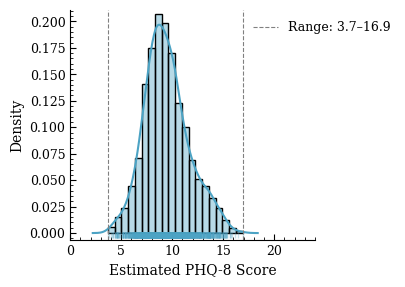

In [56]:
import seaborn as sns
all_preds = ss['all_preds'] * 24
fig, ax = plt.subplots(figsize=(100/25.4, 70/25.4), layout='constrained')

sns.histplot(all_preds, bins=20, stat='density', alpha=0.4, color='#4CA3C4', ax=ax)
sns.kdeplot(all_preds, color='#4CA3C4', linewidth=1.5, ax=ax)

# rug plot
ax.plot(all_preds, np.full_like(all_preds, -0.002), '|', color='#4CA3C4', alpha=0.3, markersize=4)

# optionally mark the actual PHQ range for contrast
ax.axvline(all_preds.min(), color='gray', linestyle='--', linewidth=0.8, label=f'Range: {all_preds.min():.1f}–{all_preds.max():.1f}')
ax.axvline(all_preds.max(), color='gray', linestyle='--', linewidth=0.8)

ax.set_xlim(0,24)
ax.set_xlabel('Estimated PHQ-8 Score')
ax.set_ylabel('Density')
#ax.set_title('Distribution of Wav2Vec2 Predictions')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(bbox_to_anchor=(0.7, 1.0))

fig.savefig('est_distribution.pdf')

In [3]:
predictions = pd.read_pickle(r"...\predictions.pkl")

In [11]:
predictions['split'].value_counts()

split
train    3104
test     1669
dev      1238
Name: count, dtype: int64

In [12]:
traindev = predictions[predictions['split'].isin(['train', 'dev'])]

spc = traindev.groupby('participant').agg(
    mean_actuals=('phq_score', 'mean'),
    mean_preds=('prediction', 'mean')
).reset_index()

thresholds = np.arange(0, 1, 0.001)
f1_scores = [f1_score((spc['mean_actuals'] >= 10).astype(int),
                       (spc['mean_preds'] >= t).astype(int))
             for t in thresholds]

best_threshold = thresholds[np.argmax(f1_scores)]
print(f'Best threshold: {best_threshold:.3f} (= {best_threshold*24:.1f} PHQ), F1: {max(f1_scores):.3f}')

Best threshold: 0.375 (= 9.0 PHQ), F1: 0.559


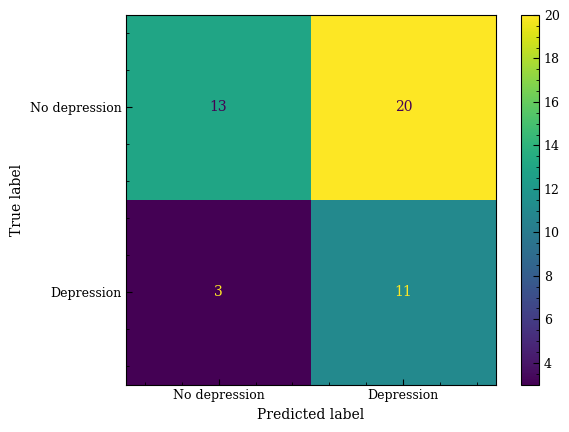

In [16]:
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=['No depression', 'Depression'])
plt.savefig('confusion_matrix.pdf')

In [22]:
EPOCH = 20
SEED = 435
N_PARTICIPANTS = 10
mm = 1 / 25.4  #mpl figsize wants inches, easier to think in mm

epe_e = epe[epe['epoch'] == EPOCH].reset_index(drop=True)
embedding_cols = [str(i) for i in range(768)]

rng = np.random.default_rng(SEED)
all_participants = epe_e['participant'].unique()
selected = rng.choice(all_participants, size=N_PARTICIPANTS, replace=False)

seg_mask = epe_e['participant'].isin(selected)
seg_df = epe_e[seg_mask].reset_index(drop=True)

#average segments per participant, only for the 10 selected
part_df_selected = (epe_e[seg_mask]
                    .groupby('participant')[embedding_cols + ['labels']]
                    .mean()
                    .reset_index())

#same but for the full test set, needed for plot 3
part_df_all = (epe_e
               .groupby('participant')[embedding_cols + ['labels']]
               .mean()
               .reset_index())

# PLOT 1: segment-level, colored by participant
X_seg = seg_df[embedding_cols].values
tsne_seg = TSNE(n_components=2, random_state=SEED, perplexity=30)
Z_seg = tsne_seg.fit_transform(X_seg)

colors_10 = plt.cm.tab10(np.linspace(0, 1, N_PARTICIPANTS))
participant_color = {p: colors_10[i] for i, p in enumerate(selected)}

fig, ax = plt.subplots(figsize=(85*mm, 85*mm), layout='constrained')
for p in selected:
    mask = seg_df['participant'] == p
    ax.scatter(Z_seg[mask, 0], Z_seg[mask, 1],
               color=participant_color[p], s=8, alpha=0.7, label=str(p))
ax.legend(title='Participant', fontsize=6, title_fontsize=7,
          markerscale=1.5, bbox_to_anchor=(1, 1), loc='upper left')
ax.set_title(f'Epoch {EPOCH} - Segment-level', fontsize=9)
ax.set_xticks([]); ax.set_yticks([])
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
fig.savefig(f'tsne_epoch{EPOCH}_segment_by_participant.pdf')
plt.close()

# PLOT 2: participant-level, selected only, colored by PHQ
X_part_sel = part_df_selected[embedding_cols].values
tsne_part_sel = TSNE(n_components=2, random_state=SEED, perplexity=min(5, N_PARTICIPANTS-1))
Z_part_sel = tsne_part_sel.fit_transform(X_part_sel)

fig, ax = plt.subplots(figsize=(85*mm, 85*mm), layout='constrained')
sc = ax.scatter(Z_part_sel[:, 0], Z_part_sel[:, 1],
                c=part_df_selected['labels'], cmap='viridis', s=40)
plt.colorbar(sc, ax=ax, label='PHQ-8')
ax.set_title(f'Epoch {EPOCH} - Participant-level (selected)', fontsize=9)
ax.set_xticks([]); ax.set_yticks([])
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
fig.savefig(f'tsne_epoch{EPOCH}_participant_selected_by_phq.pdf')
plt.close()

# PLOT 3: participant-level, all, selected 10 highlighted with black edge
X_part_all = part_df_all[embedding_cols].values
tsne_part_all = TSNE(n_components=2, random_state=SEED, perplexity=30)
Z_part_all = tsne_part_all.fit_transform(X_part_all)
is_selected = part_df_all['participant'].isin(selected)

fig, ax = plt.subplots(figsize=(85*mm, 85*mm), layout='constrained')
sc = ax.scatter(Z_part_all[:, 0], Z_part_all[:, 1],
                c=part_df_all['labels'], cmap='viridis', s=20, alpha=0.5)
ax.scatter(Z_part_all[is_selected, 0], Z_part_all[is_selected, 1],
           c=part_df_all[is_selected]['labels'], cmap='viridis',
           s=60, edgecolors='black', linewidths=0.8)
plt.colorbar(sc, ax=ax, label='PHQ-8')
ax.set_title(f'Epoch {EPOCH} - Participant-level (all)', fontsize=9)
ax.set_xticks([]); ax.set_yticks([])
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
fig.savefig(f'tsne_epoch{EPOCH}_participant_all_by_phq.pdf')
plt.close()

print(f"Epoch {EPOCH} plots saved.")

Epoch 20 plots saved.


In [30]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.manifold import TSNE

EPOCH = 20
SEED = 435
N_PARTICIPANTS = 10
mm = 1 / 25.4

epe_e = epe[epe['epoch'] == EPOCH].reset_index(drop=True)
embedding_cols = [str(i) for i in range(768)]

rng = np.random.default_rng(SEED)
all_participants = epe_e['participant'].unique()
selected = rng.choice(all_participants, size=N_PARTICIPANTS, replace=False)

seg_mask = epe_e['participant'].isin(selected)
seg_df = epe_e[seg_mask].reset_index(drop=True)

part_df_selected = (epe_e[seg_mask]
                    .groupby('participant')[embedding_cols + ['labels']]
                    .mean()
                    .reset_index())

part_df_all = (epe_e
               .groupby('participant')[embedding_cols + ['labels']]
               .mean()
               .reset_index())

# unnormalize PHQ from [0,1] to [0,24]
part_df_selected['phq_raw'] = part_df_selected['labels'] * 24
part_df_all['phq_raw'] = part_df_all['labels'] * 24

phq_min, phq_max = 0, 24
cmap_phq = 'gray_r'

# slick office palette — muted, professional
nice_colors = [
    '#2E4057', '#048A81', '#8B2FC9', '#C84B31',
    '#E8A838', '#3D6B8A', '#7A9E7E', '#C45BAA',
    '#5C5C8A', '#B5490E'
]

# ── PLOT 1: segment-level, colored by participant ─────────────────────
X_seg = seg_df[embedding_cols].values
tsne_seg = TSNE(n_components=2, random_state=SEED, perplexity=30)
Z_seg = tsne_seg.fit_transform(X_seg)

participant_color = {p: nice_colors[i] for i, p in enumerate(selected)}

fig, ax = plt.subplots(figsize=(85*mm, 85*mm), layout='constrained')
for p in selected:
    mask = seg_df['participant'] == p
    ax.scatter(Z_seg[mask, 0], Z_seg[mask, 1],
               color=participant_color[p], s=8, alpha=0.7, label=str(p))
ax.legend(title='Participant', fontsize=6, title_fontsize=7,
          markerscale=1.5, bbox_to_anchor=(1, 1), loc='upper left',
          labelspacing=0.8)
ax.set_xticks([]); ax.set_yticks([])
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
fig.savefig(f'tsne_epoch{EPOCH}_segment_by_participant.pdf')
plt.close()

# ── PLOT 2: participant-level selected, colored by PHQ ───────────────
X_part_sel = part_df_selected[embedding_cols].values
tsne_part_sel = TSNE(n_components=2, random_state=SEED, perplexity=min(5, N_PARTICIPANTS-1))
Z_part_sel = tsne_part_sel.fit_transform(X_part_sel)

fig, ax = plt.subplots(figsize=(85*mm, 85*mm), layout='constrained')
sc = ax.scatter(Z_part_sel[:, 0], Z_part_sel[:, 1],
                c=part_df_selected['phq_raw'], cmap=cmap_phq,
                vmin=phq_min, vmax=phq_max, s=40, alpha=0.7,
                edgecolors='black', linewidths=0.5)
plt.colorbar(sc, ax=ax, label='PHQ-8')
ax.set_xticks([]); ax.set_yticks([])
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
fig.savefig(f'tsne_epoch{EPOCH}_participant_selected_by_phq.pdf')
plt.close()

# ── PLOT 3: participant-level all, colored by PHQ ────────────────────
X_part_all = part_df_all[embedding_cols].values
tsne_part_all = TSNE(n_components=2, random_state=SEED, perplexity=30)
Z_part_all = tsne_part_all.fit_transform(X_part_all)

fig, ax = plt.subplots(figsize=(85*mm, 85*mm), layout='constrained')
sc = ax.scatter(Z_part_all[:, 0], Z_part_all[:, 1],
                c=part_df_all['phq_raw'], cmap=cmap_phq,
                vmin=phq_min, vmax=phq_max, s=20, alpha=0.7,
                edgecolors='black', linewidths=0.5)
plt.colorbar(sc, ax=ax, label='PHQ-8')
ax.set_xticks([]); ax.set_yticks([])
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
fig.savefig(f'tsne_epoch{EPOCH}_participant_all_by_phq.pdf')
plt.close()

print(f"Epoch {EPOCH} plots saved.")

Epoch 20 plots saved.


In [37]:
SEEDS_TO_TRY = [735, 666, 69]
EPOCH = 20

epe_e = epe[epe['epoch'] == EPOCH].reset_index(drop=True)
embedding_cols = [str(i) for i in range(768)]
all_participants = epe_e['participant'].unique()

nice_colors = [
    '#2E4057', '#048A81', '#8B2FC9', '#C84B31',
    '#E8A838', '#3D6B8A', '#7A9E7E', '#C45BAA',
    '#5C5C8A', '#B5490E'
]

X_all = epe_e[embedding_cols].values
tsne = TSNE(n_components=2, random_state=EPOCH, perplexity=30)
Z_all = tsne.fit_transform(X_all)
epe_e['tsne_0'] = Z_all[:, 0]
epe_e['tsne_1'] = Z_all[:, 1]

for seed in SEEDS_TO_TRY:
    rng = np.random.default_rng(seed)
    selected = rng.choice(all_participants, size=10, replace=False)
    
    seg_df = epe_e[epe_e['participant'].isin(selected)].reset_index(drop=True)
    X_seg = seg_df[embedding_cols].values
    
    tsne = TSNE(n_components=2, random_state=seed, perplexity=30)
    Z_seg = tsne.fit_transform(X_seg)
    
    participant_color = {p: nice_colors[i] for i, p in enumerate(selected)}

    fig, ax = plt.subplots(figsize=(85*mm, 85*mm), layout='constrained')
    for p in selected:
        mask = seg_df['participant'] == p
        ax.scatter(Z_seg[mask, 0], Z_seg[mask, 1],
                   color=participant_color[p], s=8, alpha=0.7, label=str(p))
    ax.legend(title='Participant', fontsize=6, title_fontsize=7,
              markerscale=1.5, bbox_to_anchor=(1, 1), loc='upper left',
              labelspacing=0.8)
    ax.set_xticks([]); ax.set_yticks([])
    ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
    fig.savefig(f'tsne_epoch{EPOCH}_segment_seed{seed}.pdf')
    plt.close()
    print(f"Saved seed {seed}")

Saved seed 735
Saved seed 666
Saved seed 69


In [24]:
print(epe['epoch'].unique())
print(len(epe_e))

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
0


In [ ]:
woz = pd.read_parquet(r"...\woz_preds_final.parquet")

In [7]:
#OBTAIN DF OF MEAN PREDICTIONS FOR TEST SET
test = woz[woz["split"] == "test"]
test_mean = (
    test.groupby("participant")[["phq_score", "prediction"]]
    .mean()
    .reset_index()
)
test_mean["gender"] = test_mean["participant"].map(dict(zip(test["participant"], test["gender"])))
test_mean.to_pickle("test_mean_final.pkl")

In [16]:
#LOAD ACTUAL PHQ SCORES
pre = pd.read_pickle(r"data\pickles\pre_phq.pkl")
post = pd.read_pickle(r"data\pickles\post_phq.pkl")
#OBTAIN SIDE-BY-SIDE OF ACTUAL PHQ PER LAB VISIT
actual = pre[["pre_ID", "phq8"]].merge(
    post[["post2_ID", "phq8"]],
    left_on="pre_ID",
    right_on="post2_ID",
    suffixes=("_pre", "_post")
).drop(columns="post2_ID")
actual.columns = ["participant", "pre", "post"]
#CREATE CONDITION MAPPING AND CHECK IF EQUAL BETWEEN PRE AND POST
participant_to_group = dict(zip(pre["pre_ID"], pre["group"]))
participant_to_group2 = dict(zip(post["post2_ID"], post["group"]))
print(participant_to_group == participant_to_group2)
print(pre["pre_ID"].dtype, post["post2_ID"].dtype)
print(set(pre["pre_ID"]) - set(post["post2_ID"]))  # in pre maar niet in post
print(set(post["post2_ID"]) - set(pre["pre_ID"]))  # in post maar niet in pre
#ADD CONDITION COLUMN TO ACTUAL PHQ SCORES DF
actual["mfl"] = actual["participant"].map(participant_to_group)

False
int64 int64
{58, 59, 36}
set()


In [10]:
#CREATE MIC PRED DF
mic = pd.read_parquet(r"...\mic_preds_final.parquet")
mic["phq8_pred"] = mic['prediction'] * 24
mic.to_pickle("mic.pkl")
mic_phq_pred_mean = mic['phq8_pred'].mean()
mic_phq_pred_std = mic['phq8_pred'].std()
mic['phq8_z'] = (mic['phq8_pred'] - mic_phq_pred_mean) / mic_phq_pred_std

In [12]:
#CREATE DF OF MEAN MIC PREDICTIONS
mic_mean = mic.groupby(["participant", "t"])[["phq8_pred", "phq8_z"]].mean().reset_index()
mic_mean_wide = mic_mean.pivot(index="participant", columns="t", values="phq8_pred")
mic_mean_wide.columns = ["interview_0_mu","interview_1_mu","interview_2_mu"]

In [13]:
#CREATE HOME PRED DF
home = pd.read_parquet(r"...\home_preds_final.parquet")
home["phq8_pred"] = home['prediction'] * 24
home_phq_pred_mean = home['phq8_pred'].mean()
home_phq_pred_std = home['phq8_pred'].std()
home['phq8_z'] = (home['phq8_pred'] - home_phq_pred_mean) / home_phq_pred_std

In [14]:
#CREATE DF OF MEAN HOME PREDICTIONS
home_mean = home.groupby(["participant", "day"])[["phq8_pred", "phq8_z"]].mean().reset_index()
home_mean_wide = home_mean.pivot(index="participant", columns="day", values="phq8_pred")
day_mean_column_names = [f"day_{i}_mu" for i in range(1, 15)]
home_mean_wide.columns = day_mean_column_names

In [17]:
#COMBINE SEPARATE DATAFRAMES INTO ONE
dfs = [home_mean_wide,mic_mean_wide, actual]
df = functools.reduce(lambda left, right: pd.merge(left, right, on="participant", how="outer"), dfs)
df['mfl'] = (df['mfl']).astype(bool)

In [19]:
day_column_names = [f"day_{i}" for i in range(1, 15)]

In [21]:
#CALCULATE PRE TO POST DIFF AND SLOPES
# COMPUTE SLOPE COEFFICIENTS FOR REGRESSION LINE EXPLAINING PHQ8_PRED OVER TIME
df["post-pre"] = df['post'] - df['pre']
df["slope_mu"] = df[day_mean_column_names].apply(lambda row: np.polyfit(np.arange(len(row.dropna())), row.dropna(), 1)[0], axis=1)
df.to_pickle("df_final_final.pkl")

In [5]:
df = pd.read_pickle("df_phq_grand.pkl")

In [6]:
df

,participant,day_1_mu,day_2_mu,day_3_mu,day_4_mu,day_5_mu,day_6_mu,day_7_mu,day_8_mu,day_9_mu,...,day_13_mu,day_14_mu,interview_0_mu,interview_1_mu,interview_2_mu,pre,post,mfl,post-pre,slope_mu
0,ge,11.193761,10.542491,11.137350,10.364816,10.753126,12.992692,13.036449,13.295599,12.038730,...,12.677691,7.993520,9.391712,9.681105,10.261852,9.0,13.0,True,4.0,-0.036247
1,nU,8.859687,10.169090,10.606762,10.960464,9.869771,11.334398,10.297723,10.297723,12.255694,...,11.173505,8.802755,8.100154,8.367022,8.870244,11.0,9.0,False,-2.0,0.032524
2,uz,8.032846,7.623732,8.480980,9.189160,9.230820,7.652107,7.853290,7.676075,7.763520,...,7.663500,8.254616,7.272172,7.309861,6.918517,13.0,10.0,False,-3.0,-0.090274
3,QB,NaN,5.958613,12.698463,11.578286,NaN,10.634698,11.167568,13.200056,3.713994,...,10.747514,3.689992,9.269424,9.537822,8.665606,13.0,16.0,False,3.0,-0.334337
4,pF,7.769736,7.338951,NaN,7.853671,6.476351,7.845467,6.892367,9.599910,8.655851,...,9.174934,9.174934,NaN,7.656245,9.612610,16.0,14.0,False,-2.0,0.095364
5,cP,6.822317,7.330623,7.918624,7.649095,7.836121,7.569074,7.903882,9.291319,8.348719,...,11.728988,6.347151,6.794493,NaN,6.826995,12.0,12.0,False,0.0,0.254453
6,fq,6.504083,8.411479,8.164352,6.303038,8.556618,NaN,2.723863,7.778849,7.708798,...,2.611713,NaN,7.449015,6.863696,8.591110,13.0,5.0,False,-8.0,-0.102688
7,yX,11.622544,12.526494,11.948240,12.762193,11.651977,12.855906,12.774837,14.222596,11.612821,...,NaN,11.399786,10.360432,10.299067,11.841049,8.0,8.0,True,0.0,0.073913
8,rv,11.114423,10.825270,11.426185,9.864659,10.877810,10.699715,10.750278,11.301269,10.836626,...,11.469897,10.978759,8.272669,8.990556,8.626238,18.0,7.0,True,-11.0,0.014738
9,zm,NaN,NaN,8.913394,8.117978,10.024305,8.873962,9.033295,9.281143,8.477077,...,NaN,NaN,8.530923,8.420045,11.526304,13.0,11.0,False,-2.0,-0.029482


In [40]:
df[df['participant'] == 'ge['pre', 'post']].values

array([[8., 4.]])

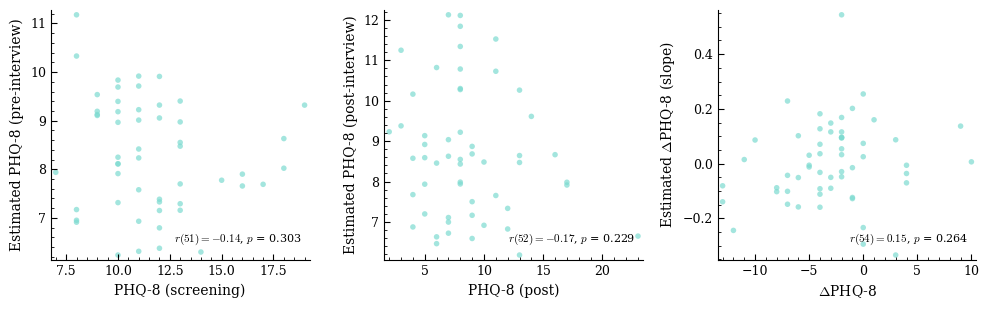

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

COLOR = '#7DDBD0'

# compute pre estimate as mean of interview_0_mu and interview_1_mu where both available
df['est_pre'] = df[['interview_0_mu', 'interview_1_mu']].mean(axis=1, skipna=False)
# where only one is available, use that one
mask_one = df['interview_0_mu'].isna() ^ df['interview_1_mu'].isna()
df.loc[mask_one & df['interview_0_mu'].notna(), 'est_pre'] = df.loc[mask_one & df['interview_0_mu'].notna(), 'interview_0_mu']
df.loc[mask_one & df['interview_1_mu'].notna(), 'est_pre'] = df.loc[mask_one & df['interview_1_mu'].notna(), 'interview_1_mu']

plots = [
    ('pre',           'est_pre',       'PHQ-8 (screening)', 'Estimated PHQ-8 (pre-interview)'),
    ('post',          'interview_2_mu', 'PHQ-8 (post)',      'Estimated PHQ-8 (post-interview)'),
    ('post_pre_diff', 'slope_mu',       r'$\Delta$PHQ-8',    r'Estimated $\Delta$PHQ-8 (slope)'),
]

df['post_pre_diff'] = df['post'] - df['pre']

fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))

for ax, (x_col, y_col, xlabel, ylabel) in zip(axes, plots):
    mask = df[x_col].notna() & df[y_col].notna()
    x = df.loc[mask, x_col].values
    y = df.loc[mask, y_col].values

    ax.scatter(x, y, color=COLOR, alpha=0.7, edgecolors='none')

    r, p = pearsonr(x, y)
    p_str = '< .001' if p < .001 else f'= {p:.3f}'
    ax.text(0.97, 0.05, f'$r({len(x)-2}) = {r:.2f}$, $p$ {p_str}',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=8)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('groningen_scatter_together.pdf')
plt.show()

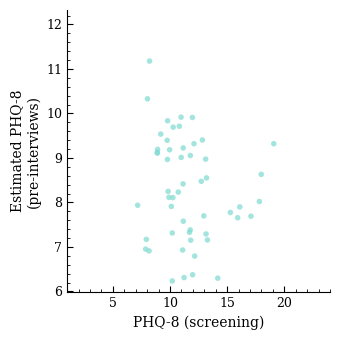

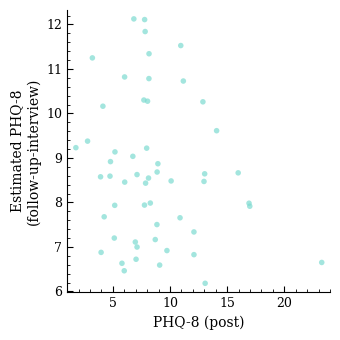

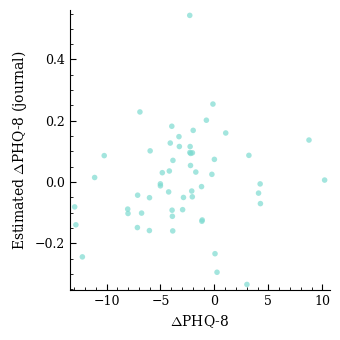

In [52]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

COLOR = '#7DDBD0'
RNG = np.random.default_rng(42)

# compute pre estimate
df['est_pre'] = df[['interview_0_mu', 'interview_1_mu']].mean(axis=1, skipna=True)

df['post_pre_diff'] = df['post'] - df['pre']

plots = [
    ('pre',           'est_pre',        'PHQ-8 (screening)',  'Estimated PHQ-8\n(pre-interviews)'),
    ('post',          'interview_2_mu', 'PHQ-8 (post)',       'Estimated PHQ-8\n(follow-up-interview)'),
    ('post_pre_diff', 'slope_mu',       r'$\Delta$PHQ-8',     r'Estimated $\Delta$PHQ-8 (journal)'),
]

# compute shared axis limits for plots 1 and 2
x_vals_12 = np.concatenate([df['pre'].dropna().values, df['post'].dropna().values])
y_vals_12 = np.concatenate([df['est_pre'].dropna().values, df['interview_2_mu'].dropna().values])
x_lim = (x_vals_12.min() - 1, x_vals_12.max() + 1)
y_lim = (y_vals_12.min() - 0.2, y_vals_12.max() + 0.2)

for i, (x_col, y_col, xlabel, ylabel) in enumerate(plots):
    fig, ax = plt.subplots(figsize=(3.5, 3.5))

    mask = df[x_col].notna() & df[y_col].notna()
    x = df.loc[mask, x_col].values
    y = df.loc[mask, y_col].values

    jitter = RNG.uniform(-0.3, 0.3, size=len(x))
    ax.scatter(x + jitter, y, color=COLOR, alpha=0.7, edgecolors='none')

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.spines[['top', 'right']].set_visible(False)

    if i < 2:
        ax.set_xlim(x_lim)
        ax.set_ylim(y_lim)

    plt.tight_layout()
    plt.savefig(f'groningen_scatter_{i+1}.pdf')
    plt.show()
    plt.close()

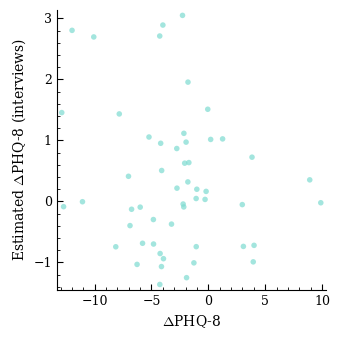

In [45]:
df['est_post'] = df['interview_2_mu']
df['delta_est'] = df['est_post'] - df['est_pre']
df['delta_real'] = df['post'] - df['pre']

fig, ax = plt.subplots(figsize=(3.5, 3.5))
mask = df['delta_est'].notna() & df['delta_real'].notna()
x = df.loc[mask, 'delta_real'].values
y = df.loc[mask, 'delta_est'].values
jitter = RNG.uniform(-0.3, 0.3, size=len(x))
ax.scatter(x + jitter, y, color=COLOR, alpha=0.7, edgecolors='none')
ax.set_xlabel(r'$\Delta$PHQ-8')
ax.set_ylabel(r'Estimated $\Delta$PHQ-8 (interviews)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('groningen_scatter_delta_interview.pdf')
plt.show()
plt.close()

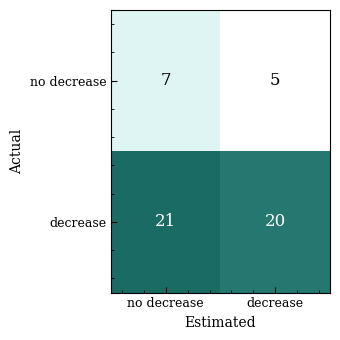

In [49]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list('teal', ['white', '#7DDBD0', '#1a6b63'])
im = ax.imshow(cm, cmap=cmap, aspect='auto')

COLOR = '#7DDBD0'

mask = df['pre'].notna() & df['post'].notna() & df['est_pre'].notna() & df['interview_2_mu'].notna()
true = (df.loc[mask, 'post'] < df.loc[mask, 'pre']).astype(int).values
pred = (df.loc[mask, 'interview_2_mu'] < df.loc[mask, 'est_pre']).astype(int).values

cm = confusion_matrix(true, pred)

fig, ax = plt.subplots(figsize=(3.5, 3.5))

im = ax.imshow(cm, cmap=cmap, aspect='auto')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['no decrease', 'decrease'])
ax.set_yticklabels(['no decrease', 'decrease'])
ax.set_xlabel('Estimated')
ax.set_ylabel('Actual')

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]),
                ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black',
                fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrix_interview_change.pdf')
plt.show()
plt.close()

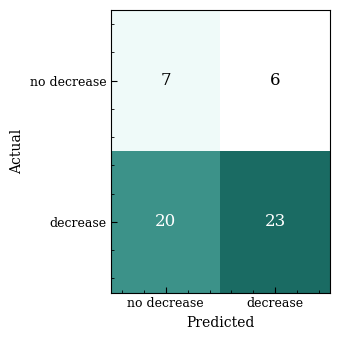

In [48]:
from sklearn.metrics import confusion_matrix
from matplotlib.colors import LinearSegmentedColormap

mask = df['slope_mu'].notna() & df['post_pre_diff'].notna()
true = (df.loc[mask, 'post_pre_diff'] < 0).astype(int).values
pred = (df.loc[mask, 'slope_mu'] < 0).astype(int).values

cm = confusion_matrix(true, pred)

cmap = LinearSegmentedColormap.from_list('teal', ['white', '#7DDBD0', '#1a6b63'])

fig, ax = plt.subplots(figsize=(3.5, 3.5))
im = ax.imshow(cm, cmap=cmap, aspect='auto')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['no decrease', 'decrease'])
ax.set_yticklabels(['no decrease', 'decrease'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]),
                ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black',
                fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrix_journal_change.pdf')
plt.show()
plt.close()

In [41]:
from sklearn.metrics import f1_score

mask = df['pre'].notna() & df['post'].notna() & df['est_pre'].notna() & df['interview_2_mu'].notna()
true = (df.loc[mask, 'post'] < df.loc[mask, 'pre']).astype(int).values
pred = (df.loc[mask, 'interview_2_mu'] < df.loc[mask, 'est_pre']).astype(int).values

f1 = f1_score(true, pred, average='macro', zero_division=0)
print(f"F1 (macro) = {f1:.4f}")

F1 (macro) = 0.4780


In [42]:
from sklearn.metrics import f1_score

mask = df['pre'].notna() & df['post'].notna() & df['est_pre'].notna() & df['interview_2_mu'].notna()
true_dir = (df.loc[mask, 'post'] < df.loc[mask, 'pre']).astype(int).values
pred_dir = (df.loc[mask, 'interview_2_mu'] < df.loc[mask, 'est_pre']).astype(int).values

f1 = f1_score(true_dir, pred_dir, average='macro', zero_division=0)
n = mask.sum()
print(f"F1 (macro) = {f1:.4f}, n = {n}")

F1 (macro) = 0.4780, n = 53


In [50]:
from scipy.stats import pearsonr
from sklearn.metrics import f1_score

df['delta_est_interview'] = df['interview_2_mu'] - df['est_pre']
df['delta_real'] = df['post'] - df['pre']

# 1. correlation delta interview vs actual delta
mask1 = df['delta_est_interview'].notna() & df['delta_real'].notna()
r1, p1 = pearsonr(df.loc[mask1, 'delta_real'], df.loc[mask1, 'delta_est_interview'])
print(f"Interview delta vs actual delta: r({mask1.sum()-2}) = {r1:.4f}, p = {p1:.3f}")

# 2. F1 direction of change from interviews
true_dir_int = (df.loc[mask1, 'delta_real'] < 0).astype(int).values
pred_dir_int = (df.loc[mask1, 'delta_est_interview'] < 0).astype(int).values
f1_int = f1_score(true_dir_int, pred_dir_int, average='macro', zero_division=0)
print(f"Interview direction F1 (macro) = {f1_int:.4f}, n = {mask1.sum()}")

# 3. correlation journal slope vs actual delta
mask2 = df['slope_mu'].notna() & df['delta_real'].notna()
r2, p2 = pearsonr(df.loc[mask2, 'delta_real'], df.loc[mask2, 'slope_mu'])
print(f"Journal slope vs actual delta: r({mask2.sum()-2}) = {r2:.4f}, p = {p2:.3f}")

# 4. F1 direction of change from journal slope
true_dir_jour = (df.loc[mask2, 'delta_real'] < 0).astype(int).values
pred_dir_jour = (df.loc[mask2, 'slope_mu'] < 0).astype(int).values
f1_jour = f1_score(true_dir_jour, pred_dir_jour, average='macro', zero_division=0)
print(f"Journal direction F1 (macro) = {f1_jour:.4f}, n = {mask2.sum()}")

Interview delta vs actual delta: r(51) = -0.1821, p = 0.192
Interview direction F1 (macro) = 0.4780, n = 53
Journal slope vs actual delta: r(54) = 0.1519, p = 0.264
Journal direction F1 (macro) = 0.4944, n = 56


In [51]:
import numpy as np
from sklearn.metrics import f1_score

np.random.seed(42)
n_trials = 10000
n = 56
p_improve = 48/56

f1s = []
for _ in range(n_trials):
    preds = np.random.choice([0, 1], size=n, p=[1-p_improve, p_improve])
    true = np.array([1]*48 + [0]*8)
    f1s.append(f1_score(true, preds, average='macro', zero_division=0))

print(f"Stratified random baseline F1 (macro) = {np.mean(f1s):.4f} (SD = {np.std(f1s):.4f})")

Stratified random baseline F1 (macro) = 0.4969 (SD = 0.0659)
